# Domain-adapted encoders (MLM / TAPT checkpoints)

Evaluates two Spanish encoders after task-adaptive pretraining with masked
language modeling on this study's own interviews (`scripts/run_mlm_adaptation.py`),
frozen, with the same classical regressor search as notebooks 01-03.
Participant level only, and each adapted arm is compared against **the same
checkpoint unadapted**, already in the log:

| Variant | Arms | Compared against |
|---|---|---|
| BETO, interviews | `E1_BETO_MLM_EPxxx` | `E1_BETO` |
| BETO, interviews + MentalRiskES | `E1_BETO_MLM_MR_EPxxx` | `E1_BETO` |
| RoBERTa-es-mental, interviews | `E7_ROBERTA_MENTAL_MLM_EPxxx` | `E7_ROBERTA_MENTAL` |

The last one is the DAPT-then-TAPT combination: a model already adapted by its
authors to 1.9M mental-health posts, adapted again here to the register of
transcribed Colombian speech.

Every checkpoint is embedded exactly like its unadapted arm — mean pooling
over the last hidden state, no prefix, the same 512-token windows — so the
adaptation is the only thing that differs.

**Each variant has its own primary checkpoint**, the saved one closest to its
minimum MLM validation perplexity: epoch 10 for BETO, epoch 25 for
RoBERTa-es-mental. That choice uses held-out *training* participants only,
never the test set. The other declared checkpoints are evaluated and reported
too, so adaptation length stays a described curve.

**All metrics below are on the held-out test participants.** Cross-validation
numbers appear only where labelled, and reflect model selection on training
data.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from src import config, data, splits, logging_utils
from src.pipeline import TARGETS, build_train_frame, compute_checkpoint_embeddings, \
    encoder_data, run_encoder, search_label
from src.plotting import plot_confusion_matrix, BAND_LABELS, SCREENING_LABELS

import json

import numpy as np

from src import metrics

## Run configuration

In [2]:
# One entry per adaptation run: arm prefix, directory (named by the same
# function run_mlm_adaptation.py writes it with), the unadapted arm it is
# compared against, and its primary checkpoint — the saved epoch closest to
# that run's minimum MLM validation perplexity, measured on held-out training
# participants only.
DECLARED = {
    "BETO, interviews": {
        "prefix": "E1_BETO_MLM",
        "dir": config.MODELS_DIR / config.mlm_output_name(
            (config.CORPUS_INTERVIEWS,), lexicon_masking=False, base_model=config.BETO_MODEL),
        "baseline": "E1_BETO",
        "primary_epoch": 10,
    },
    "BETO, interviews+mentalriskes": {
        "prefix": "E1_BETO_MLM_MR",
        "dir": config.MODELS_DIR / config.mlm_output_name(
            (config.CORPUS_INTERVIEWS, config.CORPUS_MENTALRISKES),
            lexicon_masking=False, base_model=config.BETO_MODEL),
        "baseline": "E1_BETO",
        "primary_epoch": 10,
    },
    "RoBERTa-es-mental, interviews": {
        "prefix": "E7_ROBERTA_MENTAL_MLM",
        "dir": config.MODELS_DIR / config.mlm_output_name(
            (config.CORPUS_INTERVIEWS,), lexicon_masking=False,
            base_model=config.MENTAL_ES_MODEL),
        "baseline": "E7_ROBERTA_MENTAL",
        "primary_epoch": 25,
    },
}
# Declared before training, and all four are reported for every variant.
EPOCHS = (10, 25, 50, 100)

# A variant whose adaptation has not been run yet is skipped rather than
# failing the notebook, so the others can still be evaluated.
VARIANTS = {name: spec for name, spec in DECLARED.items() if spec["dir"].exists()}
for name in DECLARED.keys() - VARIANTS.keys():
    print(f"skipping {name}: {DECLARED[name]['dir'].name} not found "
          f"(run scripts/run_mlm_adaptation.py)")

CHECKPOINTS = {f"{spec['prefix']}_EP{epoch:03d}": spec["dir"] / f"ep{epoch:03d}"
               for spec in VARIANTS.values() for epoch in EPOCHS}
BASELINES = {f"{spec['prefix']}_EP{epoch:03d}": spec["baseline"]
             for spec in VARIANTS.values() for epoch in EPOCHS}

missing = [name for name, path in CHECKPOINTS.items() if not path.exists()]
if missing:
    raise SystemExit(f"Missing checkpoints: {missing}. Run scripts/run_mlm_adaptation.py first.")

cfg = config.TrainingConfig(
    augmentation=config.AUGMENTATION_NONE,
    seeds=(42,),
    n_cv_splits=5,
    n_search_iter=0,      # 0 = sin busqueda; ver tune_model para afinar una familia
    max_tokens=512,
    chunk_stride=256,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")
print("arms:", list(CHECKPOINTS))
cfg

device: cuda
arms: ['E1_BETO_MLM_EP010', 'E1_BETO_MLM_EP025', 'E1_BETO_MLM_EP050', 'E1_BETO_MLM_EP100', 'E1_BETO_MLM_MR_EP010', 'E1_BETO_MLM_MR_EP025', 'E1_BETO_MLM_MR_EP050', 'E1_BETO_MLM_MR_EP100', 'E7_ROBERTA_MENTAL_MLM_EP010', 'E7_ROBERTA_MENTAL_MLM_EP025', 'E7_ROBERTA_MENTAL_MLM_EP050', 'E7_ROBERTA_MENTAL_MLM_EP100']


TrainingConfig(augmentation='no_augmentation', seeds=(42,), n_cv_splits=5, n_search_iter=0, beto_model='dccuchile/bert-base-spanish-wwm-cased', sentence_transformer_model='intfloat/multilingual-e5-small', mental_es_model='ELiRF/RoBERTa-es-mental-large', max_tokens=512, chunk_stride=256, tfidf_max_features=300, tfidf_ngram_range=(1, 2), tfidf_min_df=3, tfidf_max_df=0.9, tfidf_lemmatize=True, tfidf_normalize_numbers=True)

### MLM validation perplexity per checkpoint

Read from each run's `mlm_history.json`. Validation here is 11 **training**
participants held out from MLM (plus one MentalRiskES session where that
corpus is used), so this table involves no test data. Epoch 0 is the
checkpoint before adaptation; lower is better.

Compare each row only against its own epoch 0: perplexity depends on the
tokenizer, so the value of one backbone says nothing about another's.

In [3]:
rows = []
for variant, spec in VARIANTS.items():
    history = pd.DataFrame(json.loads((spec["dir"] / "mlm_history.json").read_text(encoding="utf-8")))
    history = history.set_index("epoch")
    for epoch in (0,) + EPOCHS:
        row = {"variant": variant, "epoch": epoch,
               "primary": "<-" if epoch == spec["primary_epoch"] else ""}
        row.update({c: history.loc[epoch, c] for c in history.columns if c.endswith("perplexity")})
        rows.append(row)
display(pd.DataFrame(rows).set_index(["variant", "epoch"]).round(3))

primary  val_interviews_perplexity  \
variant                       epoch                                      
BETO, interviews              0                                  6.724   
                              10         <-                      4.843   
                              25                                 5.225   
                              50                                 5.374   
                              100                                5.902   
BETO, interviews+mentalriskes 0                                  6.724   
                              10         <-                      4.875   
                              25                                 4.860   
                              50                                 5.338   
                              100                                5.656   
RoBERTa-es-mental, interviews 0                                 10.844   
                              10                                 6.220   
                              25         <-                      6.592   
                              50                                 6.988   
                              100                                6.932   

                                     val_mentalriskes_perplexity  
variant                       epoch                               
BETO, interviews              0                              NaN  
                              10                             NaN  
                              25                             NaN  
                              50                             NaN  
                              100                            NaN  
BETO, interviews+mentalriskes 0                           10.591  
                              10                          10.735  
                              25                          11.317  
                              50                          12.107  
                              100                         13.796  
RoBERTa-es-mental, interviews 0                              NaN  
                              10                             NaN  
                              25                             NaN  
                              50                             NaN  
                              100                            NaN

In [4]:
df = data.load_dataset()
train_ids, test_ids = splits.train_test_participants(df)
train_frame, groups = build_train_frame(df, train_ids, test_ids, cfg)
test_frame = df.loc[test_ids]
N_TEST = len(test_frame)
print(f"train: {len(train_frame)} rows, test: {N_TEST} held-out participants")

train: 110 rows, test: 48 held-out participants


One embedding matrix per checkpoint, embedded exactly like `E1_BETO` and cached under `results/frozen/<augmentation>/participant/embeddings/`.

In [5]:
run_dir = config.results_dir(cfg.augmentation)
combined = pd.concat([train_frame[config.QUESTIONS], test_frame[config.QUESTIONS]])

embeddings = compute_checkpoint_embeddings(combined, device, cfg, run_dir, CHECKPOINTS, family="beto")
for name, matrix in embeddings.items():
    print(f"{name}: {matrix.shape}")

E1_BETO_MLM_EP010: (158, 768)
E1_BETO_MLM_EP025: (158, 768)
E1_BETO_MLM_EP050: (158, 768)
E1_BETO_MLM_EP100: (158, 768)
E1_BETO_MLM_MR_EP010: (158, 768)
E1_BETO_MLM_MR_EP025: (158, 768)
E1_BETO_MLM_MR_EP050: (158, 768)
E1_BETO_MLM_MR_EP100: (158, 768)
E7_ROBERTA_MENTAL_MLM_EP010: (158, 1024)
E7_ROBERTA_MENTAL_MLM_EP025: (158, 1024)
E7_ROBERTA_MENTAL_MLM_EP050: (158, 1024)
E7_ROBERTA_MENTAL_MLM_EP100: (158, 1024)


In [6]:
def report_encoder(encoder_name, run_rows):
    runs = pd.DataFrame(run_rows)
    print(f"[TEST] {encoder_name}: metrics on the {N_TEST} held-out participants, per seed")
    display(runs.pivot(index="seed", columns="target", values=["rmse", "mae", "r2"]).round(3))

    # Filtered to this run's search regime: a defaults run and an earlier
    # tuned run of the same arm both live in the log, and pivoting over both
    # would collide on (model_name, seed).
    trials = logging_utils.load_trials(cfg.augmentation)
    trials = trials[(trials["encoder"] == encoder_name)
                    & (trials["search"] == search_label(cfg))]
    for target in TARGETS:
        print(f"[CROSS-VALIDATION on training data] RMSE per candidate regressor ({target}). "
              f"This is what model selection used; it is not a test score.")
        display(trials[trials["target"] == target].pivot(
            index="model_name", columns="seed", values="cv_rmse").round(3))

    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    for i, target in enumerate(TARGETS):
        target_runs = runs[runs["target"] == target]
        best_row = target_runs.loc[target_runs["rmse"].idxmin()]
        seed = int(best_row["seed"])
        plot_confusion_matrix(axes[i, 0], best_row["band_confusion_matrix"], BAND_LABELS,
                                f"{target} severity bands (seed={seed})")
        plot_confusion_matrix(axes[i, 1], best_row["screening_confusion_matrix"], SCREENING_LABELS,
                                f"{target} screening (seed={seed})")
    plt.suptitle(f"[TEST] {encoder_name}: confusion matrices, best seed per target")
    plt.tight_layout()
    plt.show()


def train_and_report(encoder_name):
    X_all, preprocessor = encoder_data(encoder_name, combined, None, embeddings, cfg)
    X_train_enc = X_all.loc[train_frame.index]
    X_test_enc = X_all.loc[test_frame.index]
    t0 = time.time()
    run_rows = run_encoder(encoder_name, X_train_enc, X_test_enc, preprocessor,
                            train_frame, test_frame, groups, cfg, notebook="03",
                            encoder_model=str(CHECKPOINTS[encoder_name]))
    print(f"{encoder_name} done in {(time.time()-t0)/60:.1f} min")
    report_encoder(encoder_name, run_rows)

## Primary checkpoints

One per variant: the saved epoch closest to that run's minimum MLM validation
perplexity (epoch 10 for BETO, epoch 25 for RoBERTa-es-mental).

### BETO + MLM (interviews), 10 epochs

E1_BETO_MLM_EP010 seed=42 target=PHQ9 best=SVR rmse=4.838 r2=0.225 (65.0s)
E1_BETO_MLM_EP010 seed=42 target=GAD7 best=SVR rmse=4.395 r2=0.237 (70.0s)
E1_BETO_MLM_EP010 done in 2.2 min
[TEST] E1_BETO_MLM_EP010: metrics on the 48 held-out participants, per seed


rmse           mae          r2       
target   GAD7   PHQ9   GAD7 PHQ9   GAD7   PHQ9
seed                                          
42      4.395  4.838  3.554  3.9  0.237  0.225

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.476
DecisionTree,7.542
ExtraTrees,5.454
GradientBoosting,5.586
KNN,5.567
LightGBM,5.548
RandomForest,5.418
Ridge,6.267
SVR,5.180


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.475
DecisionTree,5.705
ExtraTrees,4.511
GradientBoosting,4.578
KNN,4.726
LightGBM,4.764
RandomForest,4.479
Ridge,5.962
SVR,4.444


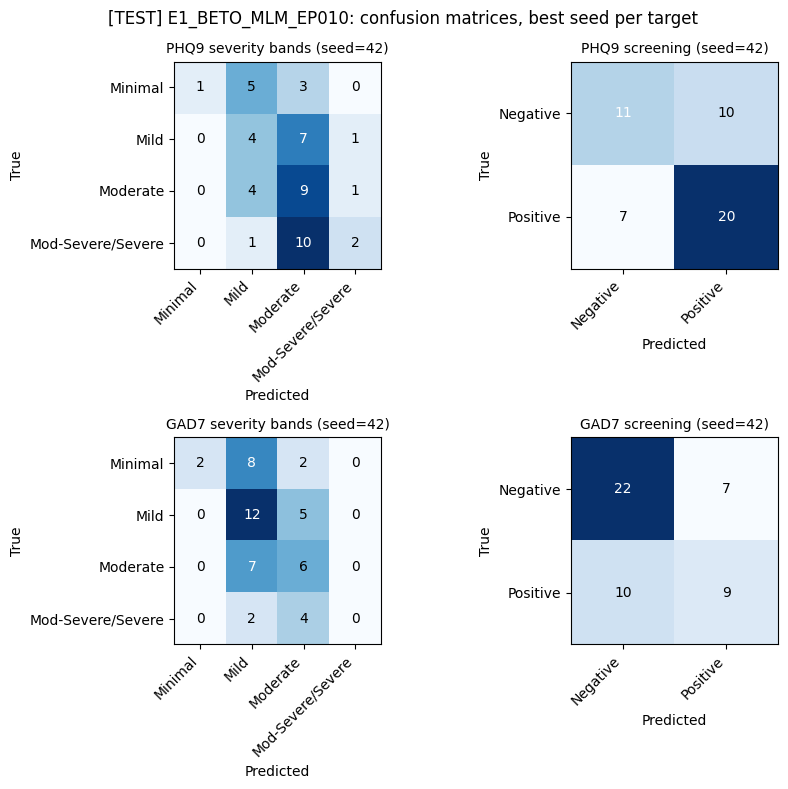

In [7]:
train_and_report("E1_BETO_MLM_EP010")

### BETO + MLM (interviews + MentalRiskES), 10 epochs

E1_BETO_MLM_MR_EP010 seed=42 target=PHQ9 best=SVR rmse=4.966 r2=0.183 (66.5s)
E1_BETO_MLM_MR_EP010 seed=42 target=GAD7 best=SVR rmse=4.393 r2=0.237 (66.1s)
E1_BETO_MLM_MR_EP010 done in 2.2 min
[TEST] E1_BETO_MLM_MR_EP010: metrics on the 48 held-out participants, per seed


rmse           mae           r2       
target   GAD7   PHQ9   GAD7  PHQ9   GAD7   PHQ9
seed                                           
42      4.393  4.966  3.518  3.97  0.237  0.183

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.319
DecisionTree,7.244
ExtraTrees,5.321
GradientBoosting,5.277
KNN,5.278
LightGBM,5.445
RandomForest,5.302
Ridge,6.375
SVR,5.083


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.560
DecisionTree,6.126
ExtraTrees,4.445
GradientBoosting,4.702
KNN,4.595
LightGBM,4.862
RandomForest,4.469
Ridge,6.043
SVR,4.426


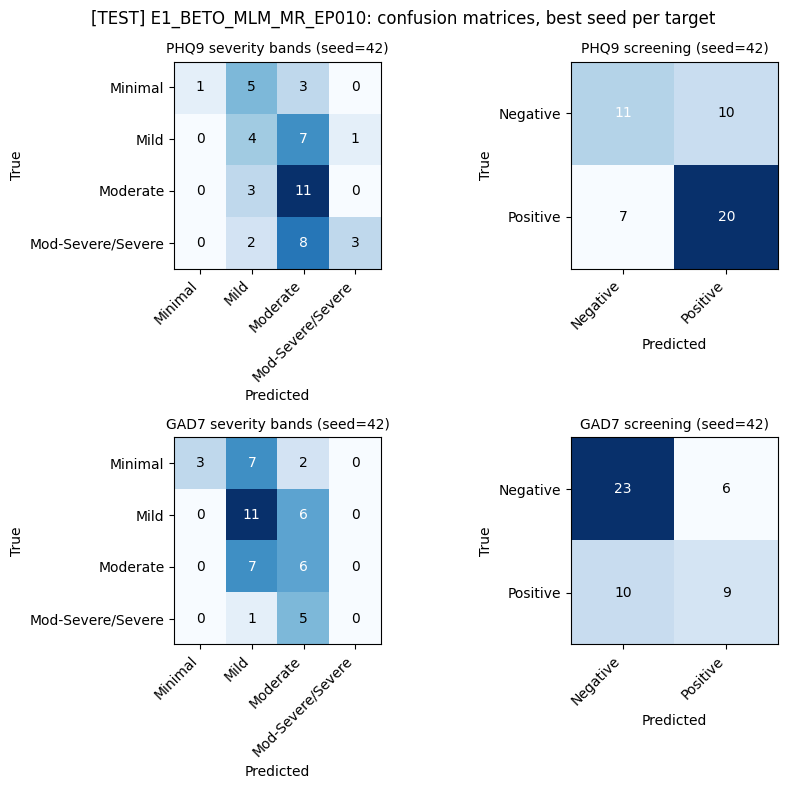

In [8]:
train_and_report("E1_BETO_MLM_MR_EP010")

### RoBERTa-es-mental + MLM (interviews), 25 epochs

Its primary checkpoint: epoch 25 is the saved epoch closest to this run's
minimum validation perplexity (the minimum itself fell at epoch 30, which was
not among the declared saves). Compared against `E7_ROBERTA_MENTAL`.

E7_ROBERTA_MENTAL_MLM_EP025 seed=42 target=PHQ9 best=AdaBoost rmse=5.230 r2=0.094 (89.1s)
E7_ROBERTA_MENTAL_MLM_EP025 seed=42 target=GAD7 best=RandomForest rmse=4.539 r2=0.186 (85.5s)
E7_ROBERTA_MENTAL_MLM_EP025 done in 2.9 min
[TEST] E7_ROBERTA_MENTAL_MLM_EP025: metrics on the 48 held-out participants, per seed


rmse          mae            r2       
target   GAD7  PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.539  5.23  3.622  4.304  0.186  0.094

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.011
DecisionTree,7.183
ExtraTrees,5.150
GradientBoosting,5.254
KNN,5.562
LightGBM,5.177
RandomForest,5.171
Ridge,5.413
SVR,5.101


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.450
DecisionTree,5.629
ExtraTrees,4.350
GradientBoosting,4.612
KNN,4.690
LightGBM,4.603
RandomForest,4.330
Ridge,5.161
SVR,4.340


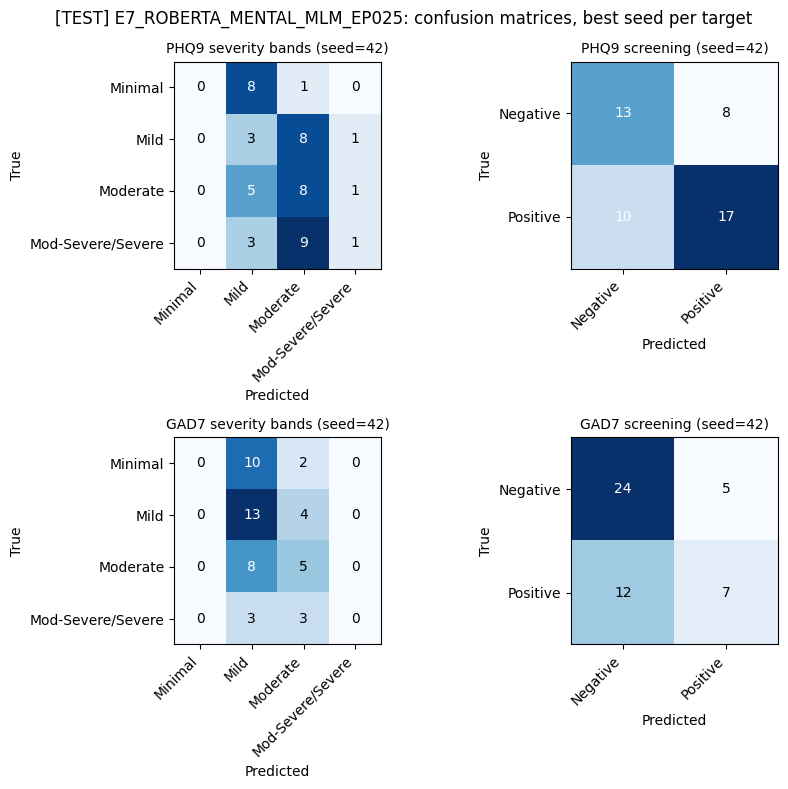

In [9]:
train_and_report("E7_ROBERTA_MENTAL_MLM_EP025")

## Remaining declared checkpoints

### BETO + MLM (interviews), 25 epochs

E1_BETO_MLM_EP025 seed=42 target=PHQ9 best=SVR rmse=4.912 r2=0.201 (65.2s)
E1_BETO_MLM_EP025 seed=42 target=GAD7 best=ExtraTrees rmse=4.632 r2=0.152 (68.3s)
E1_BETO_MLM_EP025 done in 2.2 min
[TEST] E1_BETO_MLM_EP025: metrics on the 48 held-out participants, per seed


rmse          mae            r2       
target   GAD7   PHQ9  GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.632  4.912  3.84  3.967  0.152  0.201

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.314
DecisionTree,7.343
ExtraTrees,5.359
GradientBoosting,5.400
KNN,5.595
LightGBM,5.441
RandomForest,5.345
Ridge,6.514
SVR,5.161


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.563
DecisionTree,6.645
ExtraTrees,4.417
GradientBoosting,4.638
KNN,4.715
LightGBM,4.936
RandomForest,4.425
Ridge,6.030
SVR,4.464


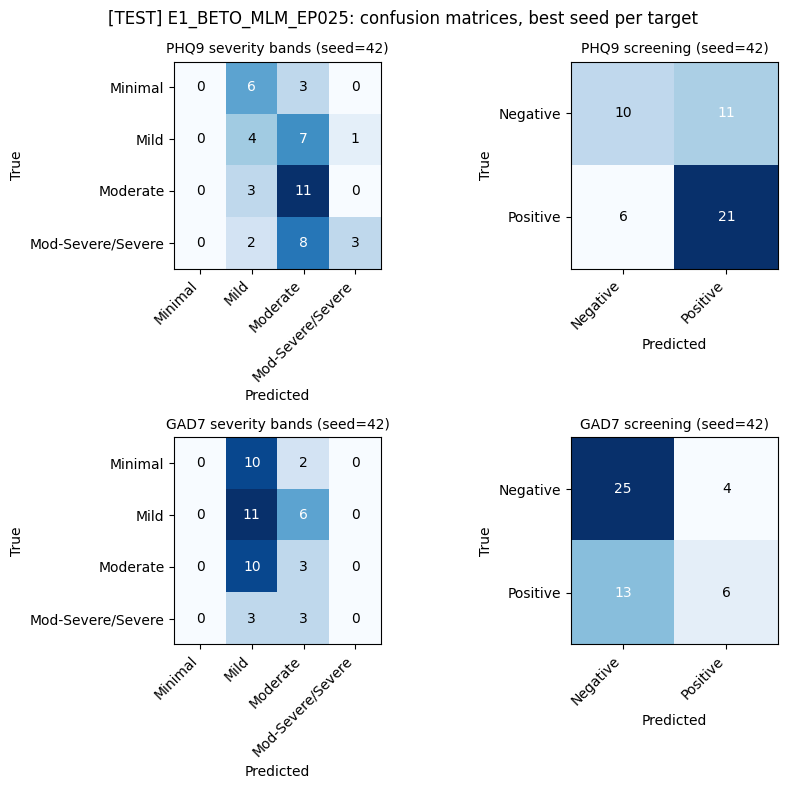

In [10]:
train_and_report("E1_BETO_MLM_EP025")

### BETO + MLM (interviews + MentalRiskES), 25 epochs

E1_BETO_MLM_MR_EP025 seed=42 target=PHQ9 best=SVR rmse=5.008 r2=0.169 (67.9s)
E1_BETO_MLM_MR_EP025 seed=42 target=GAD7 best=SVR rmse=4.472 r2=0.210 (70.6s)
E1_BETO_MLM_MR_EP025 done in 2.3 min
[TEST] E1_BETO_MLM_MR_EP025: metrics on the 48 held-out participants, per seed


rmse           mae           r2       
target   GAD7   PHQ9   GAD7   PHQ9  GAD7   PHQ9
seed                                           
42      4.472  5.008  3.629  4.033  0.21  0.169

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.446
DecisionTree,7.252
ExtraTrees,5.319
GradientBoosting,5.552
KNN,5.414
LightGBM,5.962
RandomForest,5.318
Ridge,6.397
SVR,5.152


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.448
DecisionTree,6.095
ExtraTrees,4.439
GradientBoosting,4.592
KNN,4.623
LightGBM,5.045
RandomForest,4.450
Ridge,6.251
SVR,4.438


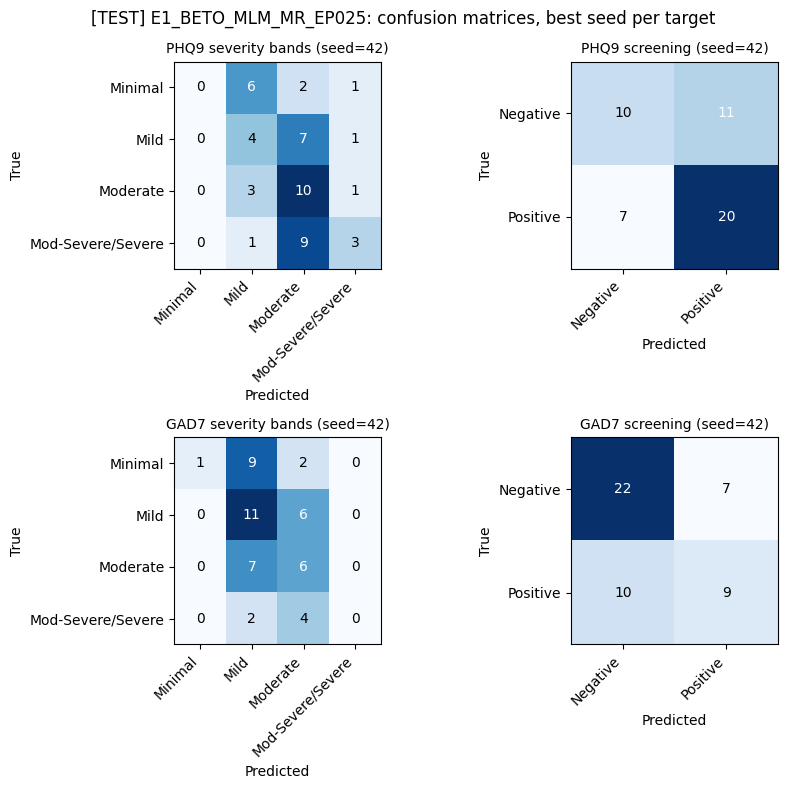

In [11]:
train_and_report("E1_BETO_MLM_MR_EP025")

### BETO + MLM (interviews), 50 epochs

E1_BETO_MLM_EP050 seed=42 target=PHQ9 best=SVR rmse=4.930 r2=0.195 (65.0s)
E1_BETO_MLM_EP050 seed=42 target=GAD7 best=AdaBoost rmse=4.492 r2=0.203 (53.2s)
E1_BETO_MLM_EP050 done in 2.0 min
[TEST] E1_BETO_MLM_EP050: metrics on the 48 held-out participants, per seed


rmse          mae            r2       
target   GAD7  PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.492  4.93  3.667  4.026  0.203  0.195

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.381
DecisionTree,7.170
ExtraTrees,5.337
GradientBoosting,5.337
KNN,5.471
LightGBM,5.719
RandomForest,5.330
Ridge,6.842
SVR,5.181


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.389
DecisionTree,6.080
ExtraTrees,4.434
GradientBoosting,4.541
KNN,4.609
LightGBM,4.655
RandomForest,4.433
Ridge,6.179
SVR,4.447


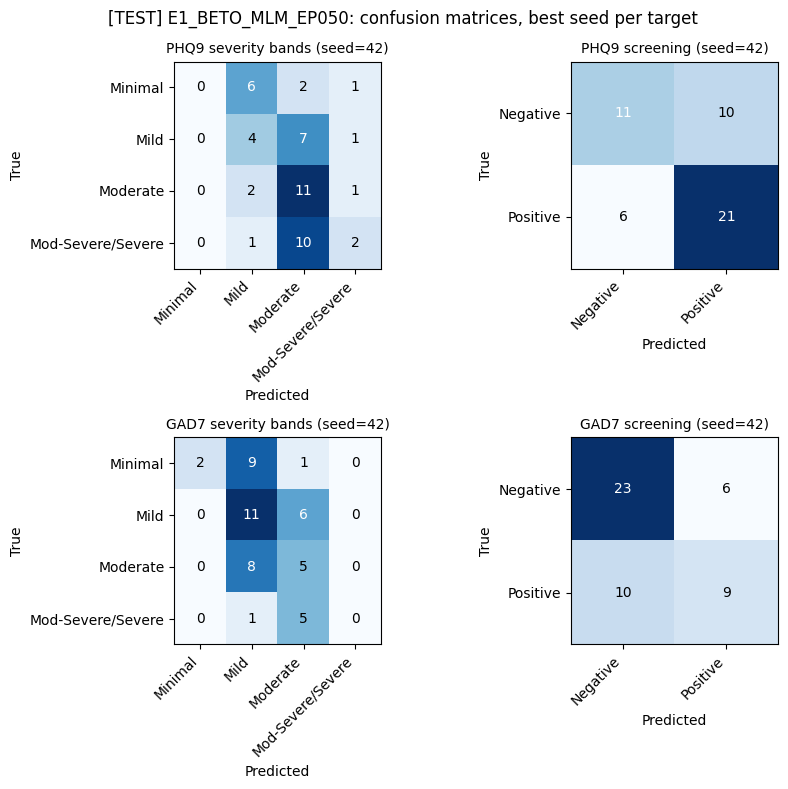

In [12]:
train_and_report("E1_BETO_MLM_EP050")

### BETO + MLM (interviews + MentalRiskES), 50 epochs

E1_BETO_MLM_MR_EP050 seed=42 target=PHQ9 best=SVR rmse=5.062 r2=0.151 (37.6s)
E1_BETO_MLM_MR_EP050 seed=42 target=GAD7 best=ExtraTrees rmse=4.637 r2=0.151 (38.0s)
E1_BETO_MLM_MR_EP050 done in 1.3 min
[TEST] E1_BETO_MLM_MR_EP050: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.637  5.062  3.785  4.138  0.151  0.151

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.445
DecisionTree,7.308
ExtraTrees,5.270
GradientBoosting,5.440
KNN,5.543
LightGBM,5.303
RandomForest,5.323
Ridge,5.975
SVR,5.143


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.462
DecisionTree,5.639
ExtraTrees,4.361
GradientBoosting,4.415
KNN,4.573
LightGBM,4.472
RandomForest,4.407
Ridge,5.792
SVR,4.374


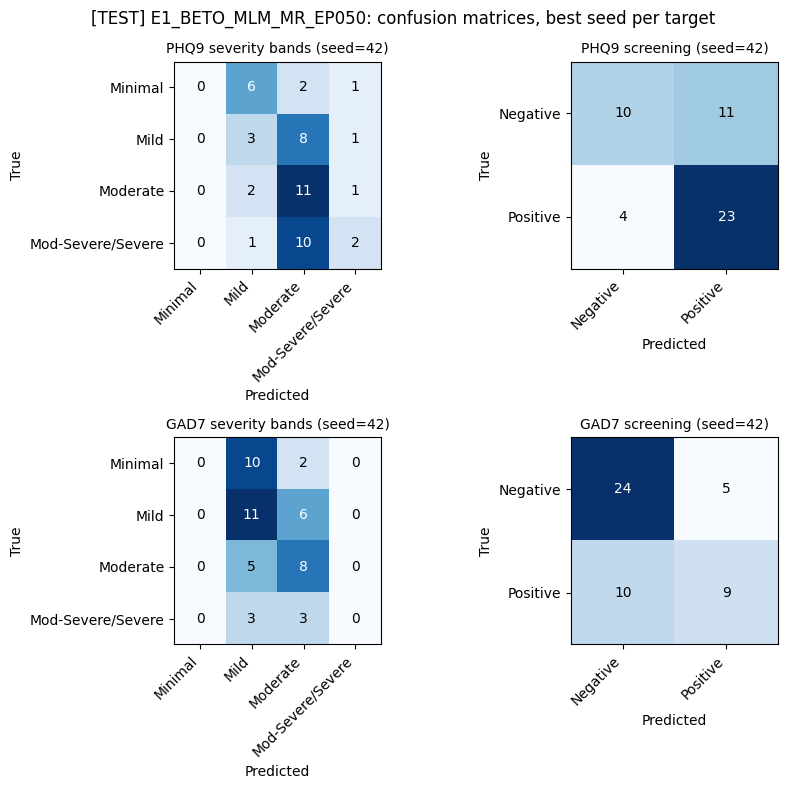

In [13]:
train_and_report("E1_BETO_MLM_MR_EP050")

### BETO + MLM (interviews), 100 epochs

E1_BETO_MLM_EP100 seed=42 target=PHQ9 best=SVR rmse=4.985 r2=0.177 (37.6s)
E1_BETO_MLM_EP100 seed=42 target=GAD7 best=AdaBoost rmse=4.790 r2=0.094 (37.6s)
E1_BETO_MLM_EP100 done in 1.3 min
[TEST] E1_BETO_MLM_EP100: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target  GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.79  4.985  3.987  4.089  0.094  0.177

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.471
DecisionTree,7.469
ExtraTrees,5.371
GradientBoosting,5.679
KNN,5.622
LightGBM,5.436
RandomForest,5.340
Ridge,6.647
SVR,5.233


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.434
DecisionTree,6.421
ExtraTrees,4.506
GradientBoosting,4.624
KNN,4.694
LightGBM,4.735
RandomForest,4.444
Ridge,5.964
SVR,4.495


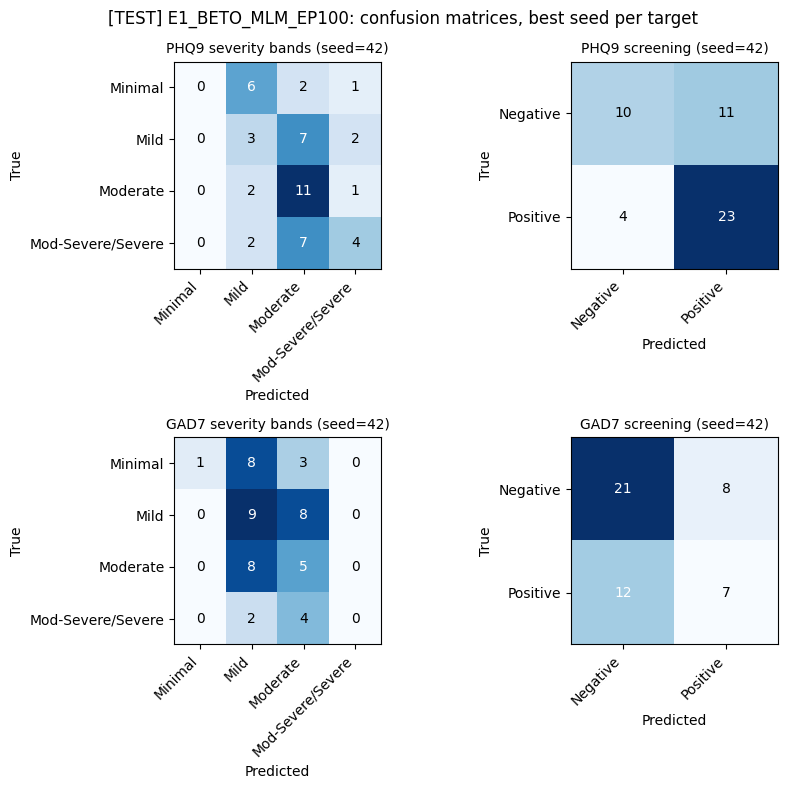

In [14]:
train_and_report("E1_BETO_MLM_EP100")

### BETO + MLM (interviews + MentalRiskES), 100 epochs

E1_BETO_MLM_MR_EP100 seed=42 target=PHQ9 best=SVR rmse=5.009 r2=0.169 (37.8s)
E1_BETO_MLM_MR_EP100 seed=42 target=GAD7 best=AdaBoost rmse=4.653 r2=0.145 (37.6s)
E1_BETO_MLM_MR_EP100 done in 1.3 min
[TEST] E1_BETO_MLM_MR_EP100: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.653  5.009  3.829  4.118  0.145  0.169

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.470
DecisionTree,7.030
ExtraTrees,5.346
GradientBoosting,5.510
KNN,5.685
LightGBM,5.643
RandomForest,5.318
Ridge,6.143
SVR,5.208


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.308
DecisionTree,5.904
ExtraTrees,4.436
GradientBoosting,4.440
KNN,4.693
LightGBM,4.348
RandomForest,4.372
Ridge,5.809
SVR,4.434


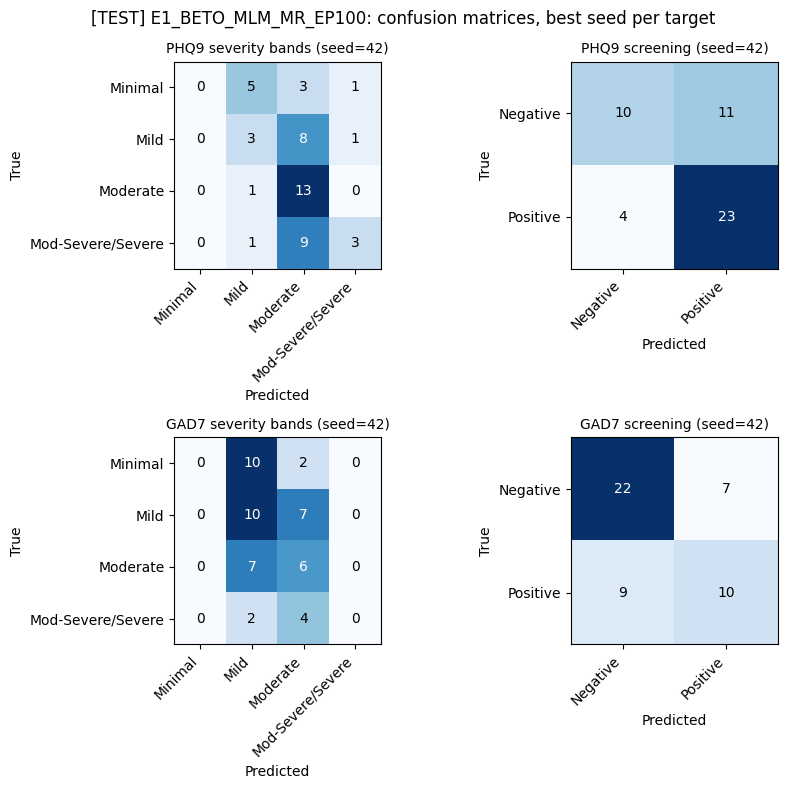

In [15]:
train_and_report("E1_BETO_MLM_MR_EP100")

### RoBERTa-es-mental + MLM (interviews), 10 epochs

E7_ROBERTA_MENTAL_MLM_EP010 seed=42 target=PHQ9 best=SVR rmse=5.101 r2=0.138 (49.2s)
E7_ROBERTA_MENTAL_MLM_EP010 seed=42 target=GAD7 best=LightGBM rmse=4.992 r2=0.016 (49.0s)
E7_ROBERTA_MENTAL_MLM_EP010 done in 1.6 min
[TEST] E7_ROBERTA_MENTAL_MLM_EP010: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.992  5.101  4.027  4.184  0.016  0.138

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.101
DecisionTree,7.199
ExtraTrees,5.244
GradientBoosting,5.290
KNN,5.436
LightGBM,5.237
RandomForest,5.149
Ridge,5.497
SVR,5.069


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.282
DecisionTree,5.523
ExtraTrees,4.365
GradientBoosting,4.270
KNN,4.684
LightGBM,4.250
RandomForest,4.301
Ridge,4.925
SVR,4.356


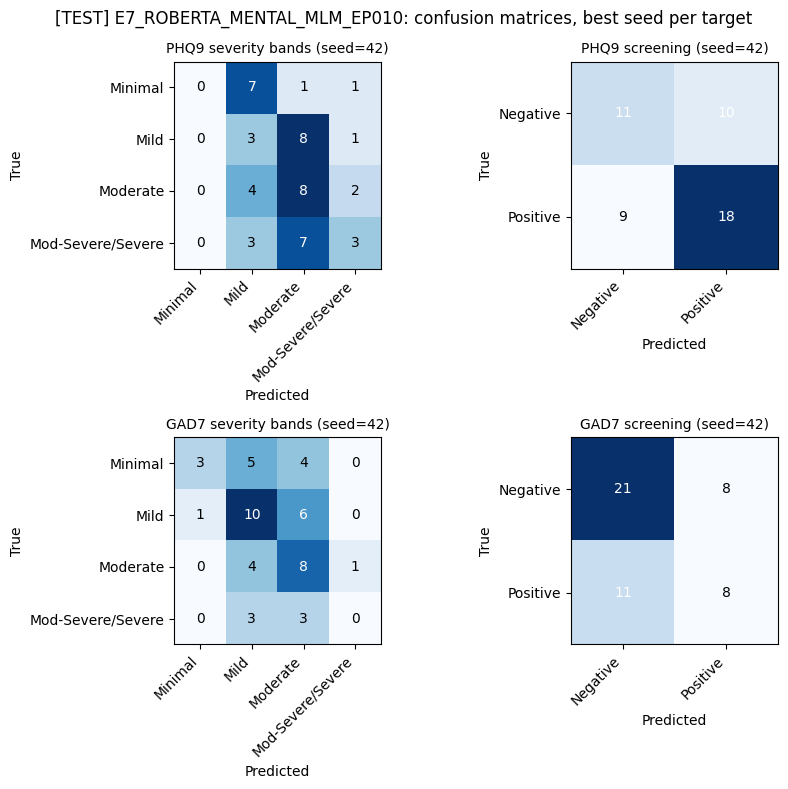

In [16]:
train_and_report("E7_ROBERTA_MENTAL_MLM_EP010")

### RoBERTa-es-mental + MLM (interviews), 50 epochs

E7_ROBERTA_MENTAL_MLM_EP050 seed=42 target=PHQ9 best=ExtraTrees rmse=5.052 r2=0.155 (48.9s)
E7_ROBERTA_MENTAL_MLM_EP050 seed=42 target=GAD7 best=GradientBoosting rmse=4.690 r2=0.131 (49.4s)
E7_ROBERTA_MENTAL_MLM_EP050 done in 1.6 min
[TEST] E7_ROBERTA_MENTAL_MLM_EP050: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target  GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.69  5.052  3.746  4.215  0.131  0.155

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.428
DecisionTree,7.122
ExtraTrees,5.268
GradientBoosting,5.509
KNN,5.546
LightGBM,5.762
RandomForest,5.318
Ridge,6.137
SVR,5.285


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.364
DecisionTree,5.360
ExtraTrees,4.400
GradientBoosting,4.278
KNN,4.654
LightGBM,4.429
RandomForest,4.415
Ridge,5.140
SVR,4.378


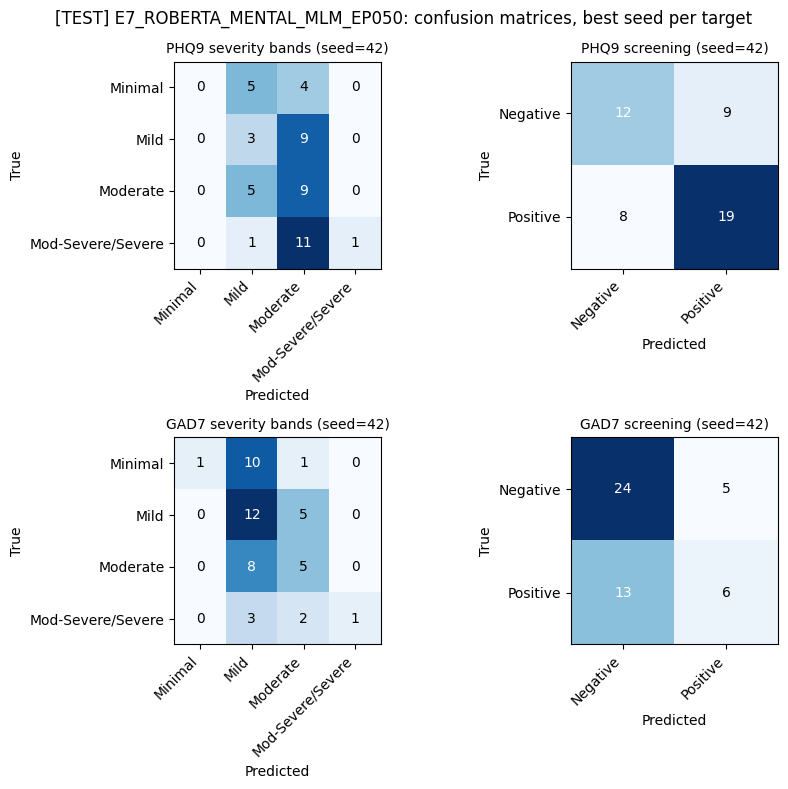

In [17]:
train_and_report("E7_ROBERTA_MENTAL_MLM_EP050")

### RoBERTa-es-mental + MLM (interviews), 100 epochs

E7_ROBERTA_MENTAL_MLM_EP100 seed=42 target=PHQ9 best=ExtraTrees rmse=5.001 r2=0.172 (51.0s)
E7_ROBERTA_MENTAL_MLM_EP100 seed=42 target=GAD7 best=LightGBM rmse=4.660 r2=0.142 (48.6s)
E7_ROBERTA_MENTAL_MLM_EP100 done in 1.7 min
[TEST] E7_ROBERTA_MENTAL_MLM_EP100: metrics on the 48 held-out participants, per seed


rmse         mae            r2       
target  GAD7   PHQ9 GAD7   PHQ9   GAD7   PHQ9
seed                                         
42      4.66  5.001  3.6  4.132  0.142  0.172

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.479
DecisionTree,6.581
ExtraTrees,5.267
GradientBoosting,5.464
KNN,5.332
LightGBM,5.290
RandomForest,5.307
Ridge,5.843
SVR,5.267


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.434
DecisionTree,6.048
ExtraTrees,4.359
GradientBoosting,4.435
KNN,4.639
LightGBM,4.177
RandomForest,4.335
Ridge,4.749
SVR,4.424


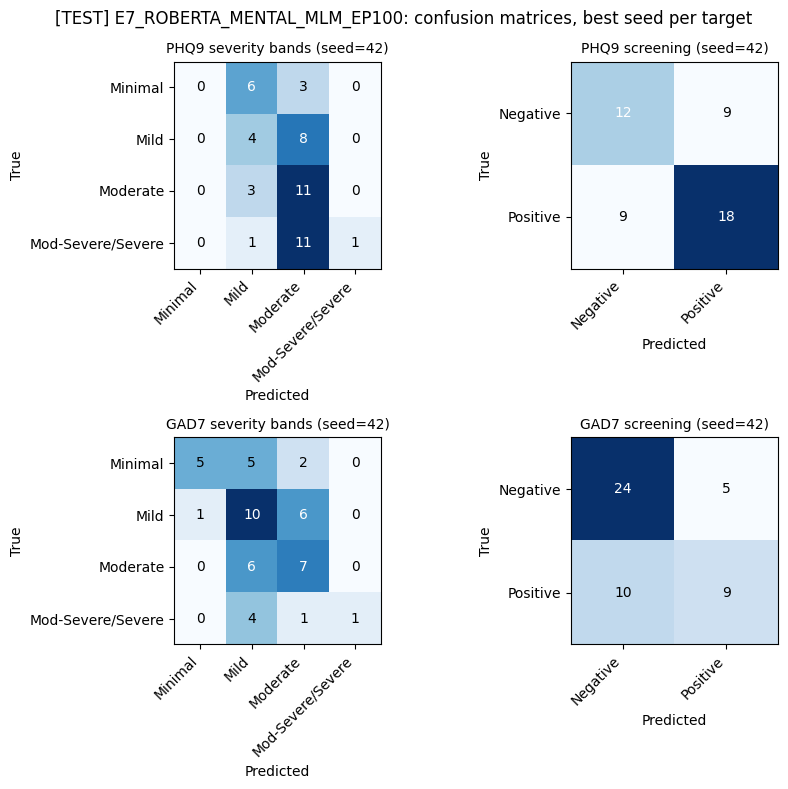

In [18]:
train_and_report("E7_ROBERTA_MENTAL_MLM_EP100")

## Adaptation against the unadapted baseline

`E1_BETO` is the same checkpoint without adaptation, already measured on the
same participants, so the difference isolates what MLM adaptation did.

In [19]:
log = logging_utils.load_all_runs()
log = log[log.augmentation == cfg.augmentation]
order = list(dict.fromkeys(list(BASELINES.values()) + list(CHECKPOINTS)))
# `search` is part of the grouping: the same arm can appear both with and
# without hyperparameter search, and averaging across the two would pool
# results from different procedures into one meaningless number.
summary = log[log.encoder.isin(order)].groupby(["encoder", "search", "target"])[
    ["rmse", "mae", "r2"]].agg(["mean", "std"]).round(3)

spread = (f"mean and SD across {len(cfg.seeds)} seeds" if len(cfg.seeds) > 1
          else f"single seed ({cfg.seeds[0]}), so the SD columns are empty")
print(f"[TEST] {spread}, on the {N_TEST} held-out participants.")
print("RMSE and MAE in PHQ-9 / GAD-7 points (lower is better); R2 is the fraction of")
print("variance explained (0 = no better than predicting the training mean).")
present = set(summary.index.get_level_values("encoder"))
display(summary.loc[[e for e in order if e in present]])

[TEST] single seed (42), so the SD columns are empty, on the 48 held-out participants.
RMSE and MAE in PHQ-9 / GAD-7 points (lower is better); R2 is the fraction of
variance explained (0 = no better than predicting the training mean).


rmse        mae         r2    
                                              mean std   mean std   mean std
encoder                     search   target                                 
E1_BETO                     defaults GAD7    4.456 NaN  3.646 NaN  0.216 NaN
                                     PHQ9    4.913 NaN  3.968 NaN  0.201 NaN
E7_ROBERTA_MENTAL           defaults GAD7    4.362 NaN  3.413 NaN  0.248 NaN
                                     PHQ9    4.987 NaN  4.070 NaN  0.176 NaN
E1_BETO_MLM_EP010           defaults GAD7    4.395 NaN  3.554 NaN  0.237 NaN
                                     PHQ9    4.838 NaN  3.900 NaN  0.225 NaN
E1_BETO_MLM_EP025           defaults GAD7    4.632 NaN  3.840 NaN  0.152 NaN
                                     PHQ9    4.912 NaN  3.967 NaN  0.201 NaN
E1_BETO_MLM_EP050           defaults GAD7    4.492 NaN  3.667 NaN  0.203 NaN
                                     PHQ9    4.930 NaN  4.026 NaN  0.195 NaN
E1_BETO_MLM_EP100           defaults GAD7    4.790 NaN  3.987 NaN  0.094 NaN
                                     PHQ9    4.985 NaN  4.089 NaN  0.177 NaN
E1_BETO_MLM_MR_EP010        defaults GAD7    4.393 NaN  3.518 NaN  0.237 NaN
                                     PHQ9    4.966 NaN  3.970 NaN  0.183 NaN
E1_BETO_MLM_MR_EP025        defaults GAD7    4.472 NaN  3.629 NaN  0.210 NaN
                                     PHQ9    5.008 NaN  4.033 NaN  0.169 NaN
E1_BETO_MLM_MR_EP050        defaults GAD7    4.637 NaN  3.785 NaN  0.151 NaN
                                     PHQ9    5.062 NaN  4.138 NaN  0.151 NaN
E1_BETO_MLM_MR_EP100        defaults GAD7    4.653 NaN  3.829 NaN  0.145 NaN
                                     PHQ9    5.009 NaN  4.118 NaN  0.169 NaN
E7_ROBERTA_MENTAL_MLM_EP010 defaults GAD7    4.992 NaN  4.027 NaN  0.016 NaN
                                     PHQ9    5.101 NaN  4.184 NaN  0.138 NaN
E7_ROBERTA_MENTAL_MLM_EP025 defaults GAD7    4.539 NaN  3.622 NaN  0.186 NaN
                                     PHQ9    5.230 NaN  4.304 NaN  0.094 NaN
E7_ROBERTA_MENTAL_MLM_EP050 defaults GAD7    4.690 NaN  3.746 NaN  0.131 NaN
                                     PHQ9    5.052 NaN  4.215 NaN  0.155 NaN
E7_ROBERTA_MENTAL_MLM_EP100 defaults GAD7    4.660 NaN  3.600 NaN  0.142 NaN
                                     PHQ9    5.001 NaN  4.132 NaN  0.172 NaN

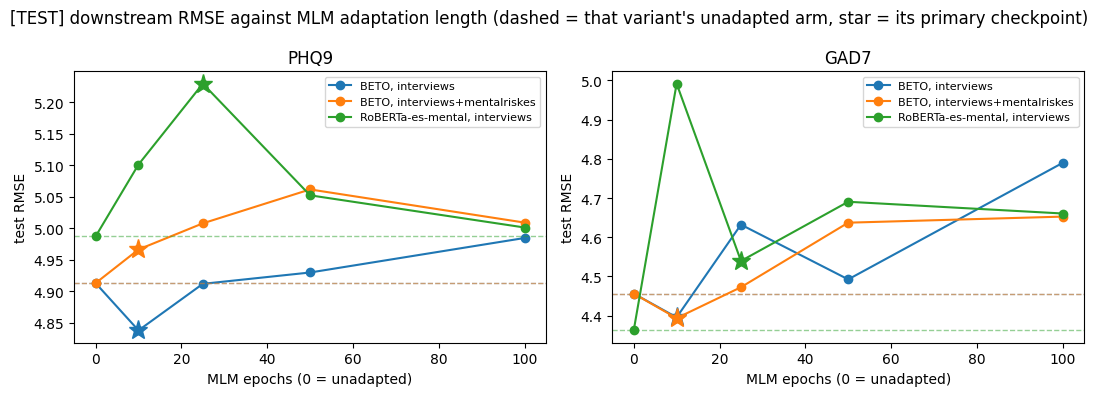

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, target in zip(axes, TARGETS):
    # One regime per curve: mixing tuned and defaults runs would put points
    # from two different procedures on the same line.
    rows = log[(log.target == target) & (log.encoder.isin(order))
                & (log.search == search_label(cfg))]
    means = rows.groupby("encoder")["rmse"].mean()
    for variant, spec in VARIANTS.items():
        # Each curve starts at its own unadapted checkpoint, so two backbones
        # can share the plot without pretending to share a baseline.
        arms = [spec["baseline"]] + [f"{spec['prefix']}_EP{epoch:03d}" for epoch in EPOCHS]
        present = [arm for arm in arms if arm in means.index]
        x = [0 if arm == spec["baseline"] else int(arm[-3:]) for arm in present]
        line, = ax.plot(x, means[present], marker="o", label=variant)
        ax.axhline(means.get(spec["baseline"], float("nan")), linestyle="--", linewidth=1,
                    color=line.get_color(), alpha=0.5)
        ax.plot([spec["primary_epoch"]],
                [means.get(f"{spec['prefix']}_EP{spec['primary_epoch']:03d}", float("nan"))],
                marker="*", markersize=14, color=line.get_color(), linestyle="none")
    ax.set_xlabel("MLM epochs (0 = unadapted)")
    ax.set_ylabel("test RMSE")
    ax.set_title(target)
    ax.legend(fontsize=8)

plt.suptitle("[TEST] downstream RMSE against MLM adaptation length "
             "(dashed = that variant's unadapted arm, star = its primary checkpoint)")
plt.tight_layout()
plt.show()

### Paired comparison against each arm's own unadapted checkpoint

Per-participant squared-error difference (adapted minus unadapted, so
**positive means the adaptation hurt**) with a paired bootstrap 95% CI and a
Wilcoxon signed-rank test, Holm-corrected within each scale across the arms
(PROTOCOL.md, Section 10). The absolute-error difference is the MAE
robustness check.

In [21]:
predictions_dir = run_dir / "predictions"
seed = cfg.seeds[0]


def load_predictions(arm, target):
    path = predictions_dir / f"{arm}__{target}__{seed}__{search_label(cfg)}.csv"
    return pd.read_csv(path).set_index("participant")


for target in TARGETS:
    rows, p_values = [], {}
    for arm, baseline_arm in BASELINES.items():
        baseline = load_predictions(baseline_arm, target)
        preds = load_predictions(arm, target).loc[baseline.index]
        assert np.allclose(preds.y_true, baseline.y_true)
        result = metrics.paired_comparison(baseline.y_true.to_numpy(),
                                           preds.y_pred.to_numpy(), baseline.y_pred.to_numpy())
        p_values[arm] = result["squared_error_wilcoxon_p"]
        rows.append({"arm": arm, "vs": baseline_arm,
                     "d_sq_error": result["squared_error_diff_mean"],
                     "ci95_low": result["squared_error_diff_ci95"][0],
                     "ci95_high": result["squared_error_diff_ci95"][1],
                     "wilcoxon_p": result["squared_error_wilcoxon_p"],
                     "d_abs_error": result["absolute_error_diff_mean"]})
    holm = metrics.holm_bonferroni(p_values)
    table = pd.DataFrame(rows).set_index("arm")
    table["holm_significant"] = [holm[arm]["significant"] for arm in table.index]
    print(f"[TEST] {target}: adapted minus its unadapted checkpoint, "
          f"n={len(baseline)} (positive = adaptation hurt)")
    display(table.round(3))

[TEST] PHQ9: adapted minus its unadapted checkpoint, n=48 (positive = adaptation hurt)


,vs,d_sq_error,ci95_low,ci95_high,wilcoxon_p,d_abs_error,holm_significant
arm,,,,,,,
E1_BETO_MLM_EP010,E1_BETO,-0.732,-2.699,1.280,0.572,-0.068,False
E1_BETO_MLM_EP025,E1_BETO,-0.011,-2.229,2.393,0.891,-0.001,False
E1_BETO_MLM_EP050,E1_BETO,0.166,-2.778,3.358,0.726,0.058,False
E1_BETO_MLM_EP100,E1_BETO,0.709,-2.668,4.379,0.291,0.121,False
E1_BETO_MLM_MR_EP010,E1_BETO,0.527,-1.721,2.767,0.644,0.002,False
E1_BETO_MLM_MR_EP025,E1_BETO,0.941,-1.691,3.811,0.264,0.065,False
E1_BETO_MLM_MR_EP050,E1_BETO,1.483,-1.647,4.929,0.389,0.170,False
E1_BETO_MLM_MR_EP100,E1_BETO,0.953,-2.025,4.170,0.479,0.150,False
E7_ROBERTA_MENTAL_MLM_EP010,E7_ROBERTA_MENTAL,1.151,-0.918,3.264,0.193,0.114,False


[TEST] GAD7: adapted minus its unadapted checkpoint, n=48 (positive = adaptation hurt)


,vs,d_sq_error,ci95_low,ci95_high,wilcoxon_p,d_abs_error,holm_significant
arm,,,,,,,
E1_BETO_MLM_EP010,E1_BETO,-0.537,-2.263,1.132,0.658,-0.092,False
E1_BETO_MLM_EP025,E1_BETO,1.599,-1.271,4.230,0.062,0.195,False
E1_BETO_MLM_EP050,E1_BETO,0.324,-2.742,3.668,0.827,0.021,False
E1_BETO_MLM_EP100,E1_BETO,3.084,0.358,6.147,0.025,0.341,False
E1_BETO_MLM_MR_EP010,E1_BETO,-0.555,-2.343,1.245,0.442,-0.128,False
E1_BETO_MLM_MR_EP025,E1_BETO,0.145,-1.623,1.896,0.688,-0.017,False
E1_BETO_MLM_MR_EP050,E1_BETO,1.645,-1.059,4.423,0.193,0.139,False
E1_BETO_MLM_MR_EP100,E1_BETO,1.789,-0.643,4.365,0.389,0.184,False
E7_ROBERTA_MENTAL_MLM_EP010,E7_ROBERTA_MENTAL,5.889,2.558,9.423,0.003,0.614,True
